# Module 1

## Task 1: Load all CSV files into PySpark DataFrames

In [6]:
%pip install pyspark
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:


from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, regexp_replace, round, lag, max as spark_max
import matplotlib.pyplot as plt
from pyspark.sql.functions import month, sum as spark_sum, dense_rank, abs as spark_abs
import pandas as pd
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [8]:
spark = SparkSession.builder \
    .appName("COVID19 Analytics Pipeline") \
    .getOrCreate()

In [9]:
full_grouped_path = "data/full_grouped.csv"
clean_complete_path = "data/covid_19_clean_complete.csv"
country_latest_path = "data/country_wise_latest.csv"
day_wise_path = "data/day_wise.csv"
usa_county_path = "data/usa_county_wise.csv"
worldometer_path = "data/worldometer_data.csv"

In [10]:
full_grouped_df = spark.read.csv(
    full_grouped_path,
    header=True,
    inferSchema=True
)

clean_complete_df = spark.read.csv(
    clean_complete_path,
    header=True,
    inferSchema=True
)

country_latest_df = spark.read.csv(
    country_latest_path,
    header=True,
    inferSchema=True
)

day_wise_df = spark.read.csv(
    day_wise_path,
    header=True,
    inferSchema=True
)

usa_county_df = spark.read.csv(
    usa_county_path,
    header=True,
    inferSchema=True
)

worldometer_df = spark.read.csv(
    worldometer_path,
    header=True,
    inferSchema=True
)

In [11]:
datasets = {
    "full_grouped": full_grouped_df,
    "covid_19_clean_complete": clean_complete_df,
    "country_wise_latest": country_latest_df,
    "day_wise": day_wise_df,
    "usa_county_wise": usa_county_df,
    "worldometer_data": worldometer_df
}

In [12]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)

    print("\nSchema:")
    df.printSchema()

    print(f"\nTotal Rows: {df.count()}")


Dataset: full_grouped

Schema:
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)


Total Rows: 35156

Dataset: covid_19_clean_complete

Schema:
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)


Total Rows: 49068

Dataset: country_wise_latest

Schema:
root
 |-- Country/Re

# Module 2

## Task 2: Handle Missing Province/State Values

In [13]:
null_province_df = clean_complete_df.filter(
    col("Province/State").isNull()
)

print("Rows with NULL Province/State:")
null_province_df.show(10, truncate=False)

Rows with NULL Province/State:
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State|Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|NULL          |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|NULL          |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|NULL          |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|NULL          |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|NULL          |Angola             |-11.2027|17.8739  |2020-01-22|0        |0     |0        |0     |Africa  

In [14]:
null_count_report = null_province_df.groupBy("Country/Region") \
    .agg(
        count("*").alias("null_province_count")
    ) \
    .orderBy(col("null_province_count").desc())

print("Country-wise NULL Province/State Count:")
null_count_report.show(truncate=False)

Country-wise NULL Province/State Count:
+--------------+-------------------+
|Country/Region|null_province_count|
+--------------+-------------------+
|Chad          |188                |
|Paraguay      |188                |
|Russia        |188                |
|Yemen         |188                |
|Senegal       |188                |
|Cabo Verde    |188                |
|Sweden        |188                |
|Guyana        |188                |
|Eritrea       |188                |
|Philippines   |188                |
|Burma         |188                |
|Djibouti      |188                |
|Malaysia      |188                |
|Singapore     |188                |
|Fiji          |188                |
|Turkey        |188                |
|Malawi        |188                |
|Western Sahara|188                |
|Iraq          |188                |
|Germany       |188                |
+--------------+-------------------+
only showing top 20 rows


In [15]:
clean_complete_df = clean_complete_df.fillna({
    "Province/State": "Unknown"
})

In [16]:
remaining_nulls = clean_complete_df.filter(
    col("Province/State").isNull()
).count()

print(f"Remaining NULL Province/State rows: {remaining_nulls}")

Remaining NULL Province/State rows: 0


In [17]:
clean_complete_df.show(10, truncate=False)

+----------------------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State              |Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+----------------------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Unknown                     |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|Unknown                     |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown                     |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|Unknown                     |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown                     |Angola     

## Task 3: Standardize Country Names

In [18]:
def standardize_country_names(df, column_name):

    return df.withColumn(
        column_name,

        when(col(column_name) == "US", "USA")
        .when(col(column_name) == "Korea, South", "South Korea")
        .when(col(column_name) == "UK", "United Kingdom")
        .when(col(column_name) == "UAE", "United Arab Emirates")
        .otherwise(col(column_name))
    )


In [19]:
full_grouped_df = standardize_country_names(
    full_grouped_df,
    "Country/Region"
)

country_latest_df = standardize_country_names(
    country_latest_df,
    "Country/Region"
)

worldometer_df = standardize_country_names(
    worldometer_df,
    "Country/Region"
)

In [20]:
full_grouped_df = full_grouped_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

country_latest_df = country_latest_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

worldometer_df = worldometer_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

In [21]:
print("Distinct Countries - full_grouped")
full_grouped_df.select("Country/Region").distinct().show(20, truncate=False)

print("Distinct Countries - country_wise_latest")
country_latest_df.select("Country/Region").distinct().show(20, truncate=False)

print("Distinct Countries - worldometer_data")
worldometer_df.select("Country/Region").distinct().show(20, truncate=False)

Distinct Countries - full_grouped
+--------------+
|Country/Region|
+--------------+
|Chad          |
|Paraguay      |
|Russia        |
|Yemen         |
|Senegal       |
|Cabo Verde    |
|Sweden        |
|Guyana        |
|Burma         |
|Eritrea       |
|Philippines   |
|Djibouti      |
|Malaysia      |
|Singapore     |
|Fiji          |
|Turkey        |
|Malawi        |
|Western Sahara|
|Iraq          |
|Germany       |
+--------------+
only showing top 20 rows
Distinct Countries - country_wise_latest
+--------------+
|Country/Region|
+--------------+
|Chad          |
|Paraguay      |
|Russia        |
|Yemen         |
|Senegal       |
|Cabo Verde    |
|Sweden        |
|Guyana        |
|Burma         |
|Eritrea       |
|Philippines   |
|Djibouti      |
|Malaysia      |
|Singapore     |
|Fiji          |
|Turkey        |
|Malawi        |
|Western Sahara|
|Iraq          |
|Germany       |
+--------------+
only showing top 20 rows
Distinct Countries - worldometer_data
+----------------+
|C

## Task 4: Remove Duplicate Daily Records

In [22]:
duplicate_full_grouped = full_grouped_df.groupBy(
    "Country/Region",
    "Date"
).count().filter("count > 1")

print("Duplicate Records in full_grouped:")
duplicate_full_grouped.show(truncate=False)

Duplicate Records in full_grouped:
+--------------+----+-----+
|Country/Region|Date|count|
+--------------+----+-----+
+--------------+----+-----+



In [23]:
duplicate_clean_complete = clean_complete_df.groupBy(
    "Country/Region",
    "Date"
).count().filter("count > 1")

print("Duplicate Records in clean_complete:")
duplicate_clean_complete.show(truncate=False)

Duplicate Records in clean_complete:
+--------------+----------+-----+
|Country/Region|Date      |count|
+--------------+----------+-----+
|China         |2020-05-01|33   |
|Netherlands   |2020-06-08|4    |
|Australia     |2020-06-10|8    |
|Denmark       |2020-06-21|2    |
|United Kingdom|2020-07-03|11   |
|Netherlands   |2020-04-20|4    |
|Australia     |2020-05-10|8    |
|Australia     |2020-07-16|8    |
|United Kingdom|2020-05-03|11   |
|Australia     |2020-05-14|8    |
|Australia     |2020-05-29|8    |
|China         |2020-06-06|33   |
|Netherlands   |2020-07-12|4    |
|France        |2020-07-13|11   |
|Canada        |2020-07-25|12   |
|Denmark       |2020-07-25|2    |
|China         |2020-01-28|33   |
|Denmark       |2020-02-25|2    |
|Australia     |2020-05-01|8    |
|France        |2020-05-27|11   |
+--------------+----------+-----+
only showing top 20 rows


In [24]:
clean_complete_df = clean_complete_df.dropDuplicates([
    "Country/Region",
    "Date"
])

In [25]:
print("Row Count After Removing Duplicates")

print(f"full_grouped_df: {full_grouped_df.count()}")
print(f"clean_complete_df: {clean_complete_df.count()}")

Row Count After Removing Duplicates
full_grouped_df: 35156
clean_complete_df: 35156


# Module 3

## Task 5: Top 10 Countries by Total Confirmed Cases

In [26]:
top_confirmed_df = country_latest_df.select(
    "Country/Region",
    "Confirmed"
)

top_10_confirmed = top_confirmed_df.orderBy(
    col("Confirmed").desc()
).limit(10)

top_10_confirmed.show(truncate=False)

+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+



In [27]:
top_10_pd = top_10_confirmed.toPandas()

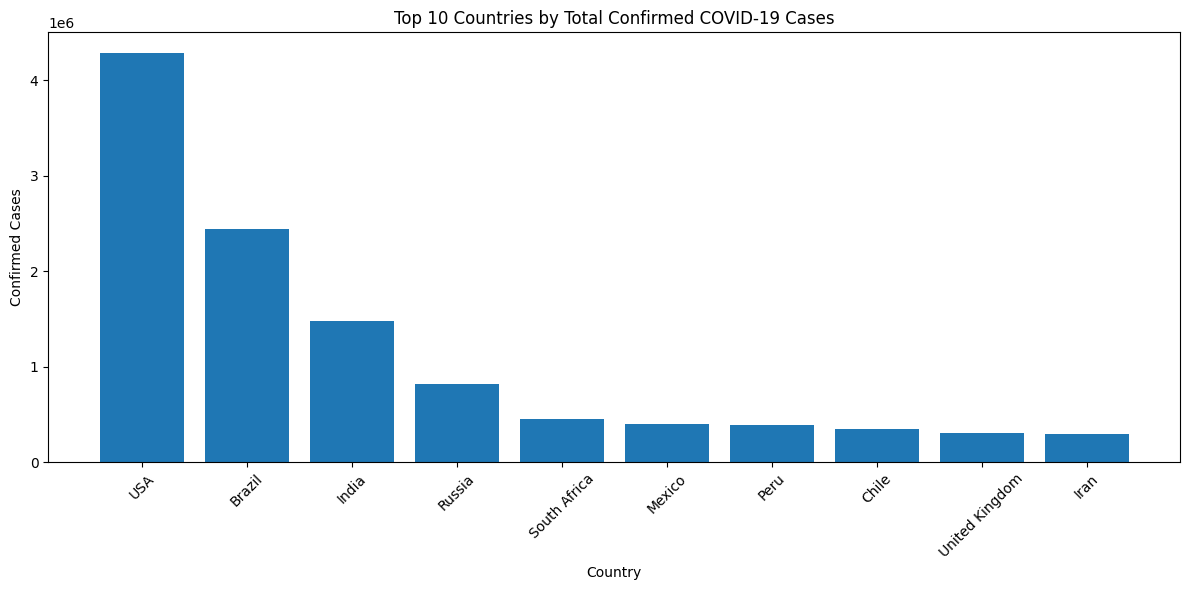

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_pd["Country/Region"],
    top_10_pd["Confirmed"]
)

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 Countries by Total Confirmed COVID-19 Cases")

plt.tight_layout()
plt.show()

## Task 6: Top 10 Countries by Death Rate

In [29]:
death_rate_df = country_latest_df.withColumn(
    "Death_Rate",
    round(
        (col("Deaths") / col("Confirmed")) * 100,
        2
    )
)

In [30]:
top_10_death_rate = death_rate_df.select(
    "Country/Region",
    "Deaths",
    "Confirmed",
    "Death_Rate"
).filter(
    col("Confirmed") > 0
).orderBy(
    col("Death_Rate").desc()
).limit(10)

top_10_death_rate.show(truncate=False)

+--------------+------+---------+----------+
|Country/Region|Deaths|Confirmed|Death_Rate|
+--------------+------+---------+----------+
|Yemen         |483   |1691     |28.56     |
|United Kingdom|45844 |301708   |15.19     |
|Belgium       |9822  |66428    |14.79     |
|Italy         |35112 |246286   |14.26     |
|France        |30212 |220352   |13.71     |
|Hungary       |596   |4448     |13.4      |
|Netherlands   |6160  |53413    |11.53     |
|Mexico        |44022 |395489   |11.13     |
|Spain         |28432 |272421   |10.44     |
|Western Sahara|1     |10       |10.0      |
+--------------+------+---------+----------+



In [31]:
top_10_death_rate_pd = top_10_death_rate.toPandas()

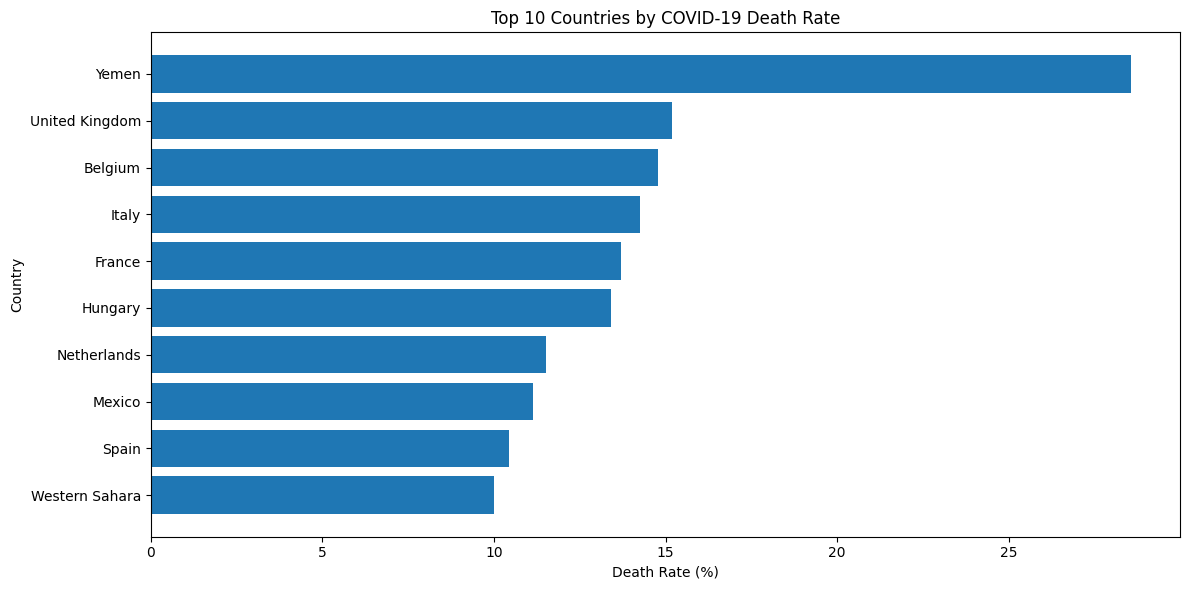

In [32]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_10_death_rate_pd["Country/Region"],
    top_10_death_rate_pd["Death_Rate"]
)

plt.xlabel("Death Rate (%)")
plt.ylabel("Country")
plt.title("Top 10 Countries by COVID-19 Death Rate")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Task 7: WHO Region-wise Total Cases

In [33]:
who_region_stats = full_grouped_df.groupBy(
    "WHO Region"
).agg(
    spark_sum("Confirmed").alias("Total_Confirmed"),
    spark_sum("Deaths").alias("Total_Deaths"),
    spark_sum("Recovered").alias("Total_Recovered")
)

who_region_stats.show(truncate=False)

+---------------------+---------------+------------+---------------+
|WHO Region           |Total_Confirmed|Total_Deaths|Total_Recovered|
+---------------------+---------------+------------+---------------+
|Europe               |248879793      |19271040    |123202075      |
|Western Pacific      |26374411       |932430      |18861950       |
|Africa               |21791827       |439978      |11193730       |
|Eastern Mediterranean|74082892       |1924029     |48050703       |
|Americas             |402261194      |19359292    |157069444      |
|South-East Asia      |55118365       |1458134     |30030327       |
+---------------------+---------------+------------+---------------+



In [34]:
who_region_pd = who_region_stats.toPandas()

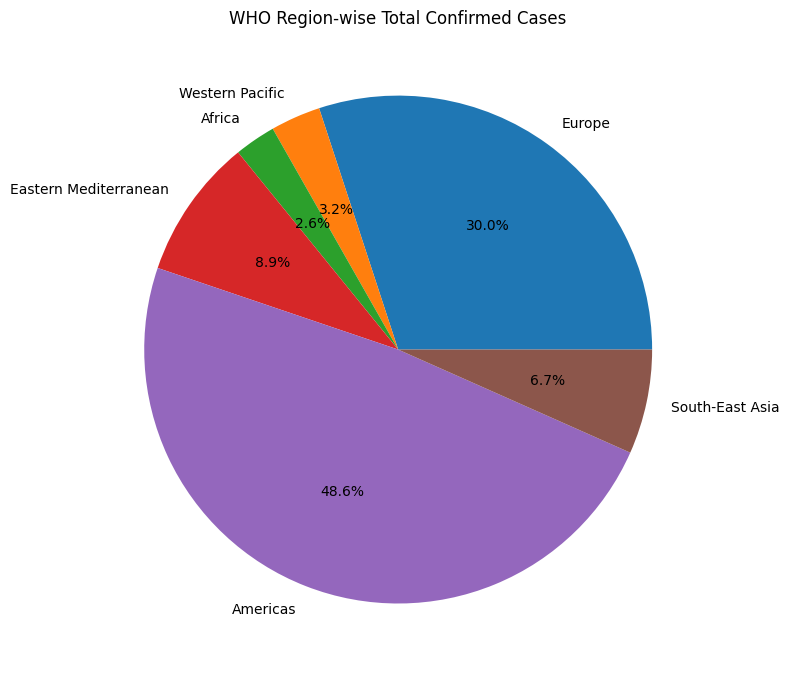

In [35]:
plt.figure(figsize=(8, 8))

plt.pie(
    who_region_pd["Total_Confirmed"],
    labels=who_region_pd["WHO Region"],
    autopct="%1.1f%%"
)

plt.title("WHO Region-wise Total Confirmed Cases")

plt.tight_layout()
plt.show()

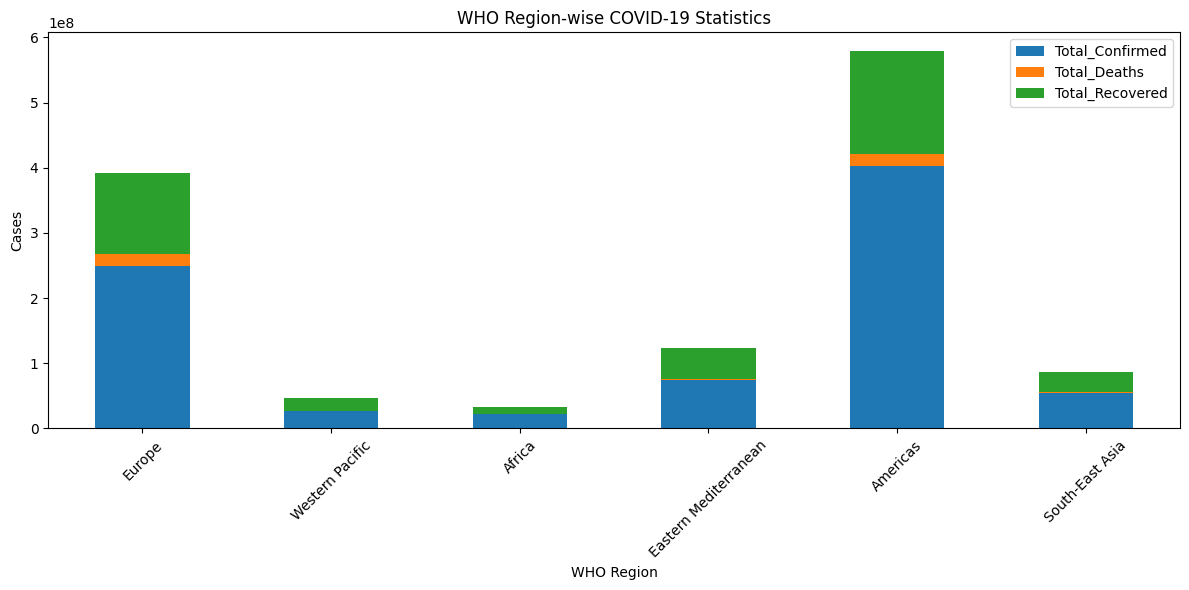

In [36]:
who_region_pd.set_index("WHO Region")[
    ["Total_Confirmed", "Total_Deaths", "Total_Recovered"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("WHO Region-wise COVID-19 Statistics")
plt.xlabel("WHO Region")
plt.ylabel("Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Module 4

## Task 8: Daily Global New Cases Trend

In [37]:
daily_new_cases_df = day_wise_df.select(
    "Date",
    "New cases"
)

daily_new_cases_df = daily_new_cases_df.orderBy(
    col("Date")
)

daily_new_cases_df.show(truncate=False)

+----------+---------+
|Date      |New cases|
+----------+---------+
|2020-01-22|0        |
|2020-01-23|99       |
|2020-01-24|287      |
|2020-01-25|493      |
|2020-01-26|684      |
|2020-01-27|809      |
|2020-01-28|2651     |
|2020-01-29|588      |
|2020-01-30|2068     |
|2020-01-31|1693     |
|2020-02-01|2111     |
|2020-02-02|4749     |
|2020-02-03|3100     |
|2020-02-04|4011     |
|2020-02-05|3745     |
|2020-02-06|3159     |
|2020-02-07|3532     |
|2020-02-08|2734     |
|2020-02-09|3027     |
|2020-02-10|2538     |
+----------+---------+
only showing top 20 rows


In [38]:
daily_new_cases_pd = daily_new_cases_df.toPandas()

In [39]:
daily_new_cases_pd["Date"] = pd.to_datetime(
    daily_new_cases_pd["Date"]
)

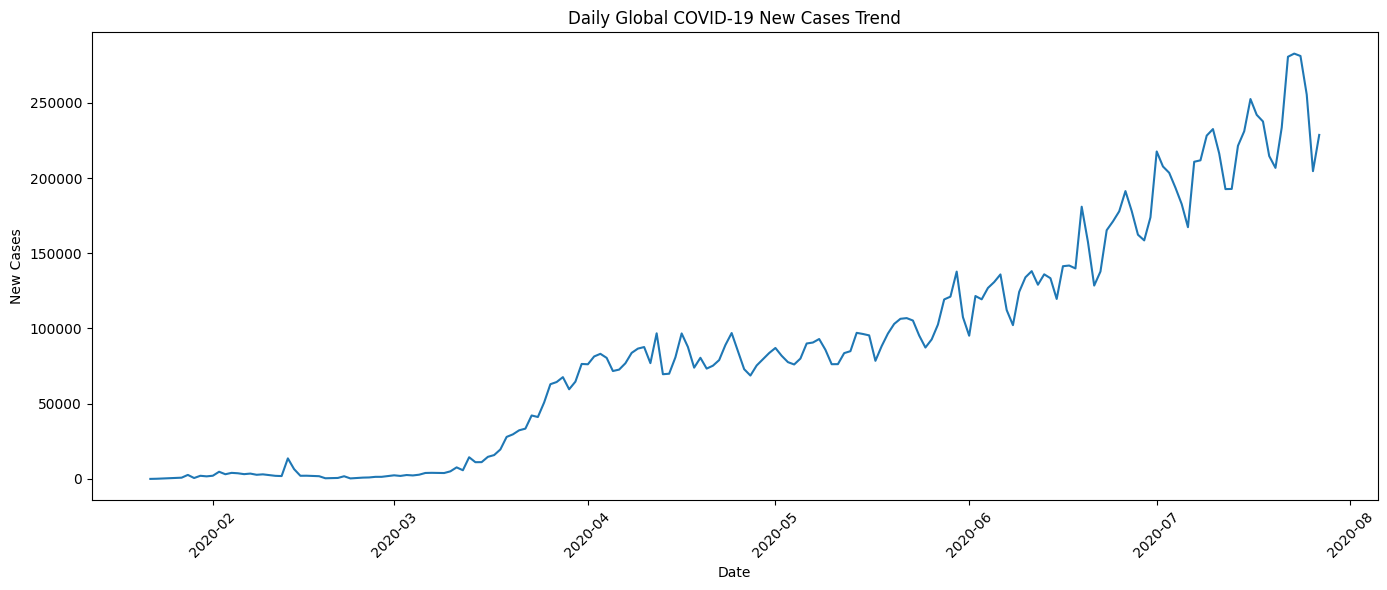

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_new_cases_pd["Date"],
    daily_new_cases_pd["New cases"]
)

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("Daily Global COVID-19 New Cases Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Task 9: Daily Global Death Growth Trend


In [41]:
death_window = Window.orderBy("Date")

In [42]:
death_growth_df = day_wise_df.withColumn(
    "Previous_Day_Deaths",
    lag("New deaths", 1).over(death_window)
)

In [43]:
death_growth_df = death_growth_df.withColumn(
    "Death_Growth_Percentage",
    when(
        col("Previous_Day_Deaths") == 0,
        None
    ).otherwise(
        round(
            (col("New deaths") / col("Previous_Day_Deaths")) * 100,
            2
        )
    )
)

In [44]:
death_growth_df = death_growth_df.select(
    "Date",
    "New deaths",
    "Previous_Day_Deaths",
    "Death_Growth_Percentage"
)

In [45]:
death_growth_df = death_growth_df.filter(
    col("Death_Growth_Percentage").isNotNull()
)

death_growth_df.show(truncate=False)

+----------+----------+-------------------+-----------------------+
|Date      |New deaths|Previous_Day_Deaths|Death_Growth_Percentage|
+----------+----------+-------------------+-----------------------+
|2020-01-24|8         |1                  |800.0                  |
|2020-01-25|16        |8                  |200.0                  |
|2020-01-26|14        |16                 |87.5                   |
|2020-01-27|26        |14                 |185.71                 |
|2020-01-28|49        |26                 |188.46                 |
|2020-01-29|2         |49                 |4.08                   |
|2020-01-30|38        |2                  |1900.0                 |
|2020-01-31|42        |38                 |110.53                 |
|2020-02-01|46        |42                 |109.52                 |
|2020-02-02|103       |46                 |223.91                 |
|2020-02-03|64        |103                |62.14                  |
|2020-02-04|66        |64                 |103.1

In [46]:
death_growth_pd = death_growth_df.toPandas()

In [47]:
death_growth_pd["Date"] = pd.to_datetime(
    death_growth_pd["Date"]
)


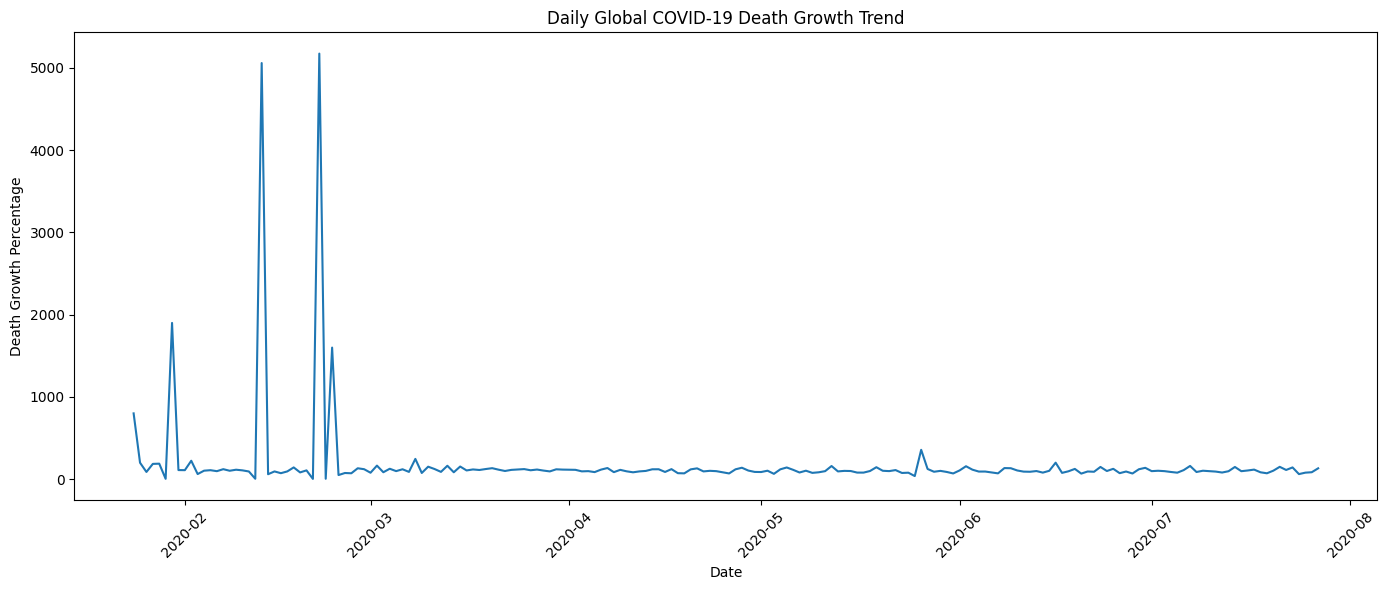

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(
    death_growth_pd["Date"],
    death_growth_pd["Death_Growth_Percentage"]
)

plt.xlabel("Date")
plt.ylabel("Death Growth Percentage")
plt.title("Daily Global COVID-19 Death Growth Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Task 10: Monthly COVID Case Growth

In [49]:
monthly_df = full_grouped_df.withColumn(
    "Month",
    month(col("Date"))
)

In [50]:
monthly_cases = monthly_df.groupBy("Month").agg(
    spark_sum("Confirmed").alias("Total_Confirmed")
).orderBy("Month")

In [51]:
monthly_cases.show()

+-----+---------------+
|Month|Total_Confirmed|
+-----+---------------+
|    1|          38534|
|    2|        1663437|
|    3|        9002815|
|    4|       63391662|
|    5|      144990399|
|    6|      246525787|
|    7|      362895848|
+-----+---------------+



In [52]:
monthly_pd = monthly_cases.toPandas()

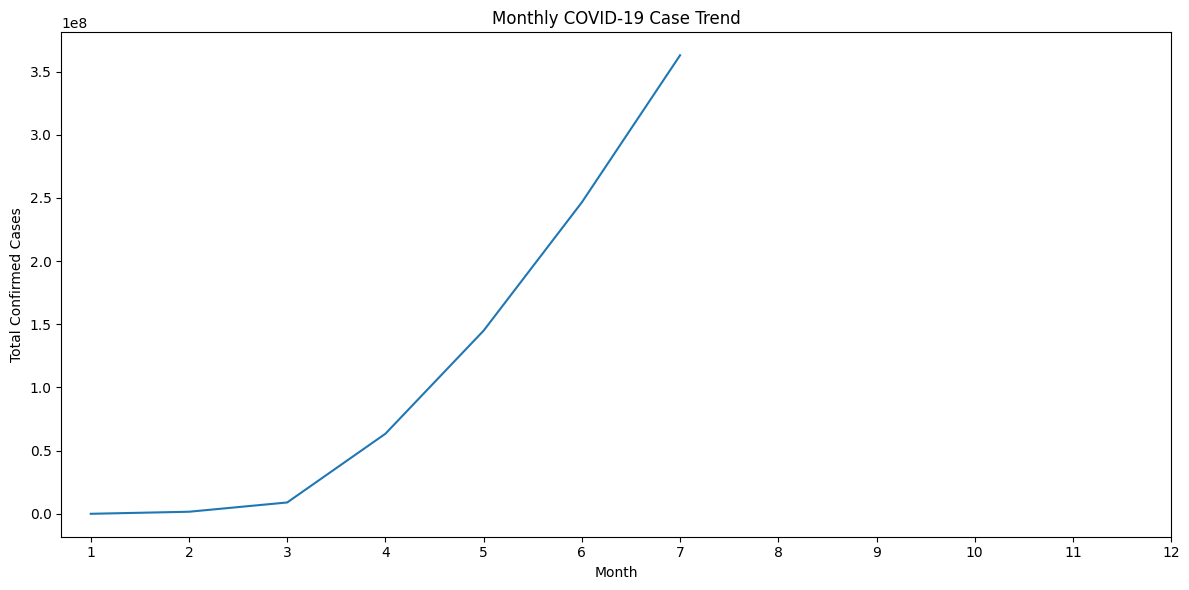

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["Total_Confirmed"]
)

plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")
plt.title("Monthly COVID-19 Case Trend")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

# Module 5

## Task 11: Top 5 Most Affected Countries Per WHO Region

In [54]:
window_spec = Window.partitionBy("WHO Region").orderBy(
    col("Confirmed").desc()
)

In [55]:
ranked_df = country_latest_df.withColumn(
    "rank",
    dense_rank().over(window_spec)
)


In [56]:
top5_per_region = ranked_df.filter(
    col("rank") <= 5
)

top5_per_region.select(
    "WHO Region",
    "Country/Region",
    "Confirmed",
    "rank"
).orderBy("WHO Region", "rank").show(50, truncate=False)

+---------------------+--------------+---------+----+
|WHO Region           |Country/Region|Confirmed|rank|
+---------------------+--------------+---------+----+
|Africa               |South Africa  |452529   |1   |
|Africa               |Nigeria       |41180    |2   |
|Africa               |Ghana         |33624    |3   |
|Africa               |Algeria       |27973    |4   |
|Africa               |Kenya         |17975    |5   |
|Americas             |USA           |4290259  |1   |
|Americas             |Brazil        |2442375  |2   |
|Americas             |Mexico        |395489   |3   |
|Americas             |Peru          |389717   |4   |
|Americas             |Chile         |347923   |5   |
|Eastern Mediterranean|Iran          |293606   |1   |
|Eastern Mediterranean|Pakistan      |274289   |2   |
|Eastern Mediterranean|Saudi Arabia  |268934   |3   |
|Eastern Mediterranean|Iraq          |112585   |4   |
|Eastern Mediterranean|Qatar         |109597   |5   |
|Europe               |Russi

In [57]:
top5_pd = top5_per_region.toPandas()

top5_pd["Country_Label"] = top5_pd["WHO Region"] + " - " + top5_pd["Country/Region"]

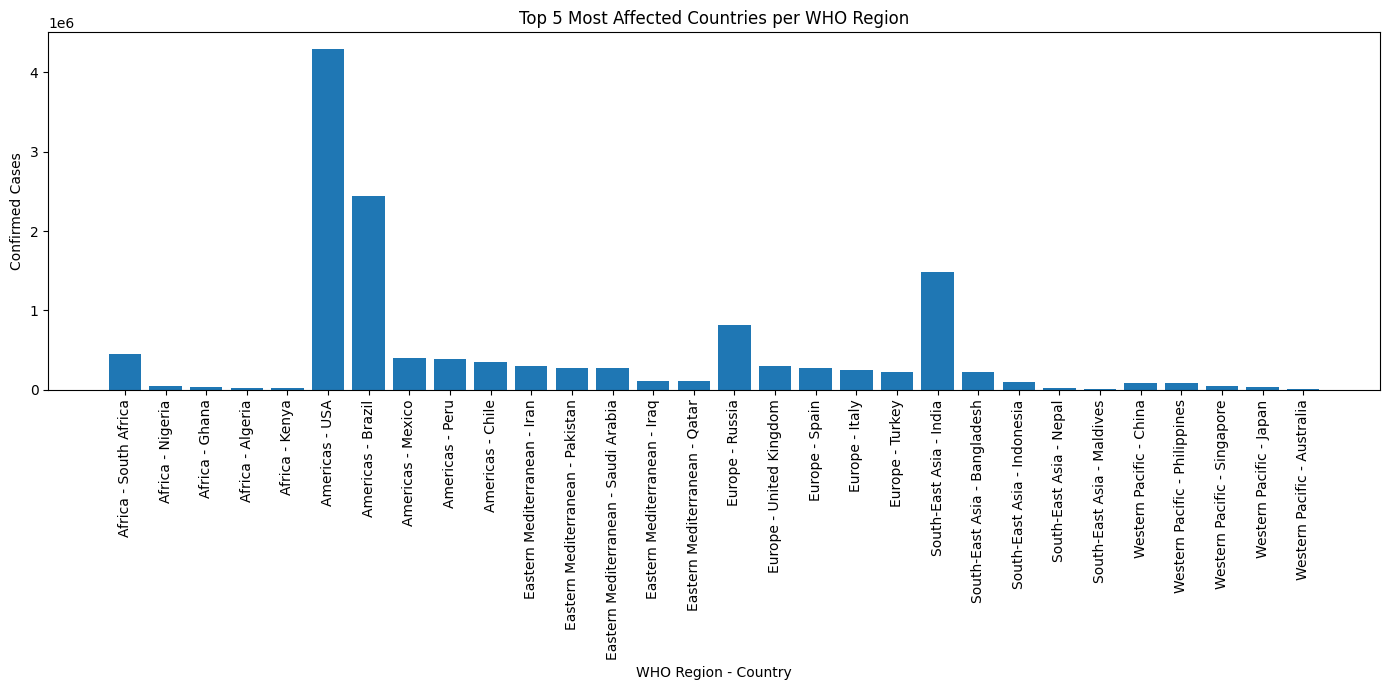

In [58]:

plt.figure(figsize=(14, 7))

plt.bar(
    top5_pd["Country_Label"],
    top5_pd["Confirmed"]
)

plt.xlabel("WHO Region - Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 5 Most Affected Countries per WHO Region")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Task 12: Country-wise Daily Case Increase


In [59]:
country_window = Window.partitionBy("Country/Region").orderBy("Date")

In [60]:
daily_change_df = full_grouped_df.withColumn(
    "Previous_Confirmed",
    lag("Confirmed", 1).over(country_window)
)

In [61]:
daily_change_df = daily_change_df.withColumn(
    "Daily_Increase",
    col("Confirmed") - col("Previous_Confirmed")
)

daily_change_df = daily_change_df.filter(
    col("Daily_Increase").isNotNull()
)

daily_change_df.select(
    "Country/Region",
    "Date",
    "Confirmed",
    "Previous_Confirmed",
    "Daily_Increase"
).show(20, truncate=False)

+--------------+----------+---------+------------------+--------------+
|Country/Region|Date      |Confirmed|Previous_Confirmed|Daily_Increase|
+--------------+----------+---------+------------------+--------------+
|Afghanistan   |2020-01-23|0        |0                 |0             |
|Afghanistan   |2020-01-24|0        |0                 |0             |
|Afghanistan   |2020-01-25|0        |0                 |0             |
|Afghanistan   |2020-01-26|0        |0                 |0             |
|Afghanistan   |2020-01-27|0        |0                 |0             |
|Afghanistan   |2020-01-28|0        |0                 |0             |
|Afghanistan   |2020-01-29|0        |0                 |0             |
|Afghanistan   |2020-01-30|0        |0                 |0             |
|Afghanistan   |2020-01-31|0        |0                 |0             |
|Afghanistan   |2020-02-01|0        |0                 |0             |
|Afghanistan   |2020-02-02|0        |0                 |0       

In [62]:
country_example = "India"

country_trend_pd = daily_change_df.filter(
    col("Country/Region") == country_example
).select(
    "Date",
    "Daily_Increase"
).toPandas()

In [63]:
country_trend_pd["Date"] = pd.to_datetime(country_trend_pd["Date"])

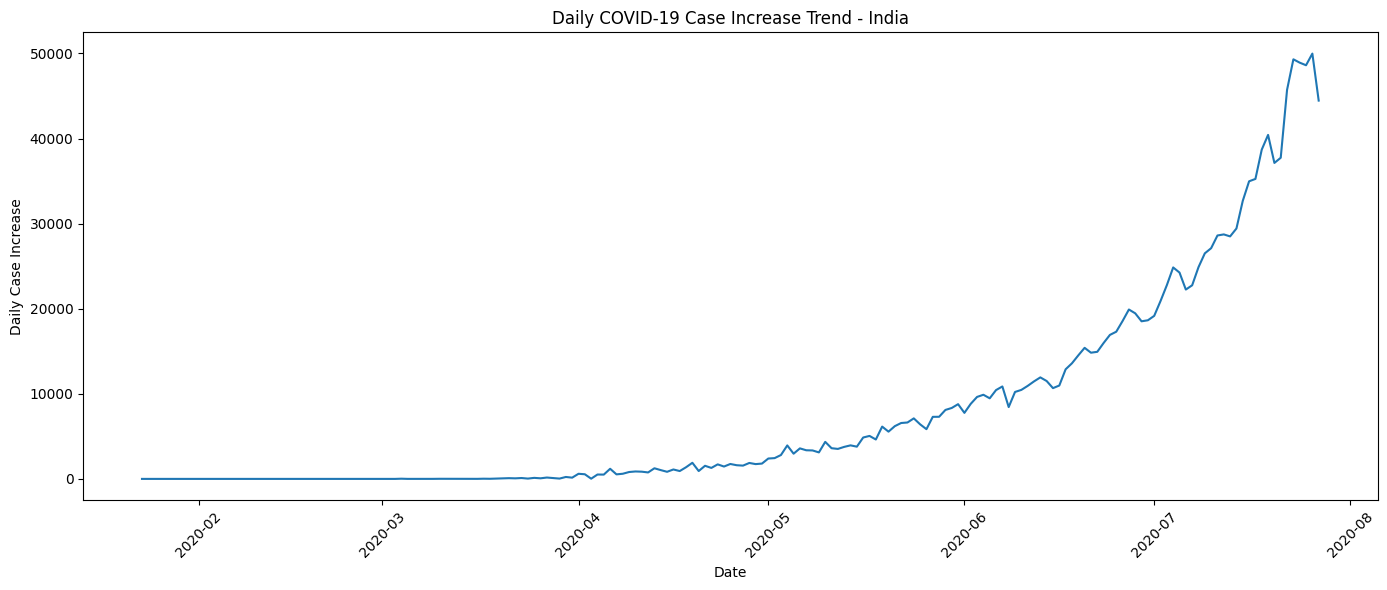

In [64]:
plt.figure(figsize=(14, 6))

plt.plot(
    country_trend_pd["Date"],
    country_trend_pd["Daily_Increase"]
)

plt.xlabel("Date")
plt.ylabel("Daily Case Increase")
plt.title(f"Daily COVID-19 Case Increase Trend - {country_example}")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Module 6

## Task 13: Compare Latest Dataset Sources

In [65]:
cw = country_latest_df.select(
    col("Country/Region").alias("Country"),
    col("Confirmed").alias("Confirmed_cw"),
    col("Deaths").alias("Deaths_cw"),
    col("Recovered").alias("Recovered_cw")
)

wm = worldometer_df.select(
    col("Country/Region").alias("Country"),
    col("TotalCases").alias("Confirmed_wm"),
    col("TotalDeaths").alias("Deaths_wm"),
    col("TotalRecovered").alias("Recovered_wm")
)

In [66]:
joined_df = cw.join(wm, on="Country", how="inner")

In [67]:
diff_df = joined_df.withColumn(
    "Confirmed_Diff",
    spark_abs(col("Confirmed_cw") - col("Confirmed_wm"))
).withColumn(
    "Deaths_Diff",
    spark_abs(col("Deaths_cw") - col("Deaths_wm"))
).withColumn(
    "Recovered_Diff",
    spark_abs(col("Recovered_cw") - col("Recovered_wm"))
)

In [68]:
mismatch_df = diff_df.filter(
    (col("Confirmed_Diff") > 10000) |
    (col("Deaths_Diff") > 1000) |
    (col("Recovered_Diff") > 10000)
)

In [69]:
mismatch_df.select(
    "Country",
    "Confirmed_cw", "Confirmed_wm", "Confirmed_Diff",
    "Deaths_cw", "Deaths_wm", "Deaths_Diff",
    "Recovered_cw", "Recovered_wm", "Recovered_Diff"
).orderBy(col("Confirmed_Diff").desc()).show(50, truncate=False)

+------------------+------------+------------+--------------+---------+---------+-----------+------------+------------+--------------+
|Country           |Confirmed_cw|Confirmed_wm|Confirmed_Diff|Deaths_cw|Deaths_wm|Deaths_Diff|Recovered_cw|Recovered_wm|Recovered_Diff|
+------------------+------------+------------+--------------+---------+---------+-----------+------------+------------+--------------+
|USA               |4290259     |5032179     |741920        |148011   |162804   |14793      |1325804     |2576668     |1250864       |
|India             |1480073     |2025409     |545336        |33408    |41638    |8230       |951166      |1377384     |426218        |
|Brazil            |2442375     |2917562     |475187        |87618    |98644    |11026      |1846641     |2047660     |201019        |
|Colombia          |257101      |357710      |100609        |8777     |11939    |3162       |131161      |192355      |61194         |
|South Africa      |452529      |538184      |85655    

## Task 14: Population vs Total Cases


In [70]:
infection_df = worldometer_df.withColumn(
    "Infection_Rate",
    round(
        (col("TotalCases") / col("Population")) * 100,
        2
    )
)

In [71]:
top_infection = infection_df.select(
    "Country/Region",
    "TotalCases",
    "Population",
    "Infection_Rate"
).filter(
    col("Population") > 0
).orderBy(
    col("Infection_Rate").desc()
).limit(10)

top_infection.show(truncate=False)

+--------------+----------+----------+--------------+
|Country/Region|TotalCases|Population|Infection_Rate|
+--------------+----------+----------+--------------+
|Qatar         |112092    |2807805   |3.99          |
|French Guiana |8127      |299385    |2.71          |
|Bahrain       |42889     |1706669   |2.51          |
|San Marino    |699       |33938     |2.06          |
|Chile         |366671    |19132514  |1.92          |
|Panama        |71418     |4321282   |1.65          |
|Kuwait        |70045     |4276658   |1.64          |
|Oman          |80713     |5118446   |1.58          |
|USA           |5032179   |331198130 |1.52          |
|Vatican City  |12        |801       |1.5           |
+--------------+----------+----------+--------------+



In [72]:
top_infection_pd = top_infection.toPandas()

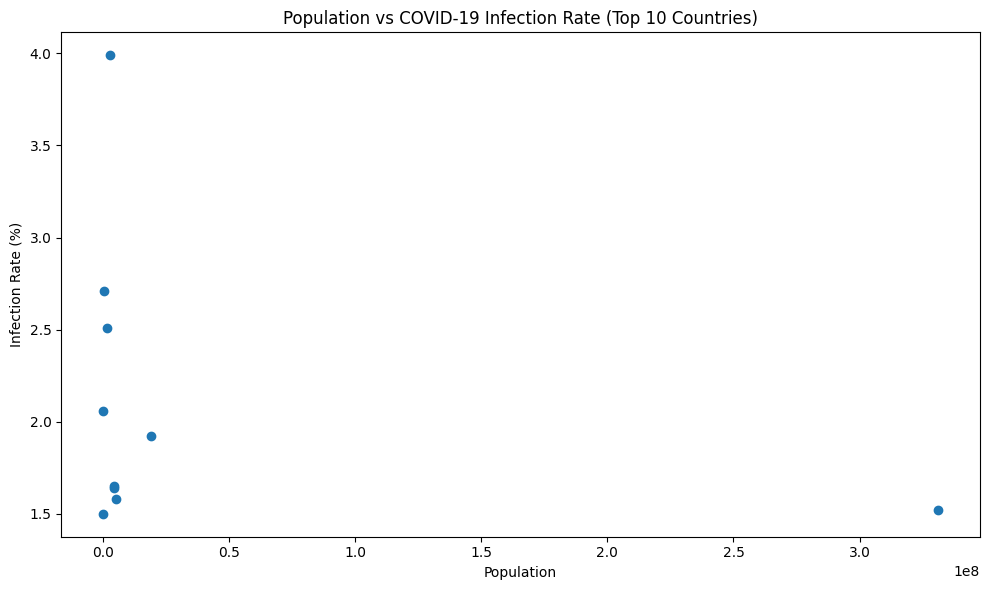

In [73]:
pdf = top_infection.toPandas()

plt.figure(figsize=(10, 6))

plt.scatter(
    pdf["Population"],
    pdf["Infection_Rate"]
)

plt.xlabel("Population")
plt.ylabel("Infection Rate (%)")
plt.title("Population vs COVID-19 Infection Rate (Top 10 Countries)")

plt.tight_layout()
plt.show()

# Module 7

## Task 15: USA State-wise Case Distribution

In [74]:
usa_clean_df = usa_county_df.filter(
    col("Province_State").isNotNull() &
    col("Admin2").isNotNull()
)

In [75]:
state_wise_counties = usa_clean_df.groupBy(
    "Province_State"
).agg(
    count("Admin2").alias("Total_Counties")
).orderBy(
    col("Total_Counties").desc()
)

In [76]:
state_wise_counties.show(50, truncate=False)

+--------------+--------------+
|Province_State|Total_Counties|
+--------------+--------------+
|Texas         |48128         |
|Georgia       |30268         |
|Virginia      |25380         |
|Kentucky      |22936         |
|Missouri      |22184         |
|Kansas        |20116         |
|Illinois      |19552         |
|North Carolina|19176         |
|Iowa          |18988         |
|Tennessee     |18236         |
|Nebraska      |17860         |
|Indiana       |17672         |
|Ohio          |16920         |
|Minnesota     |16732         |
|Michigan      |16356         |
|Mississippi   |15792         |
|Puerto Rico   |15040         |
|Oklahoma      |14852         |
|Arkansas      |14476         |
|Wisconsin     |13912         |
|Pennsylvania  |12972         |
|Alabama       |12972         |
|Florida       |12972         |
|South Dakota  |12784         |
|Louisiana     |12408         |
|Colorado      |12408         |
|New York      |12032         |
|California    |11280         |
|Montana

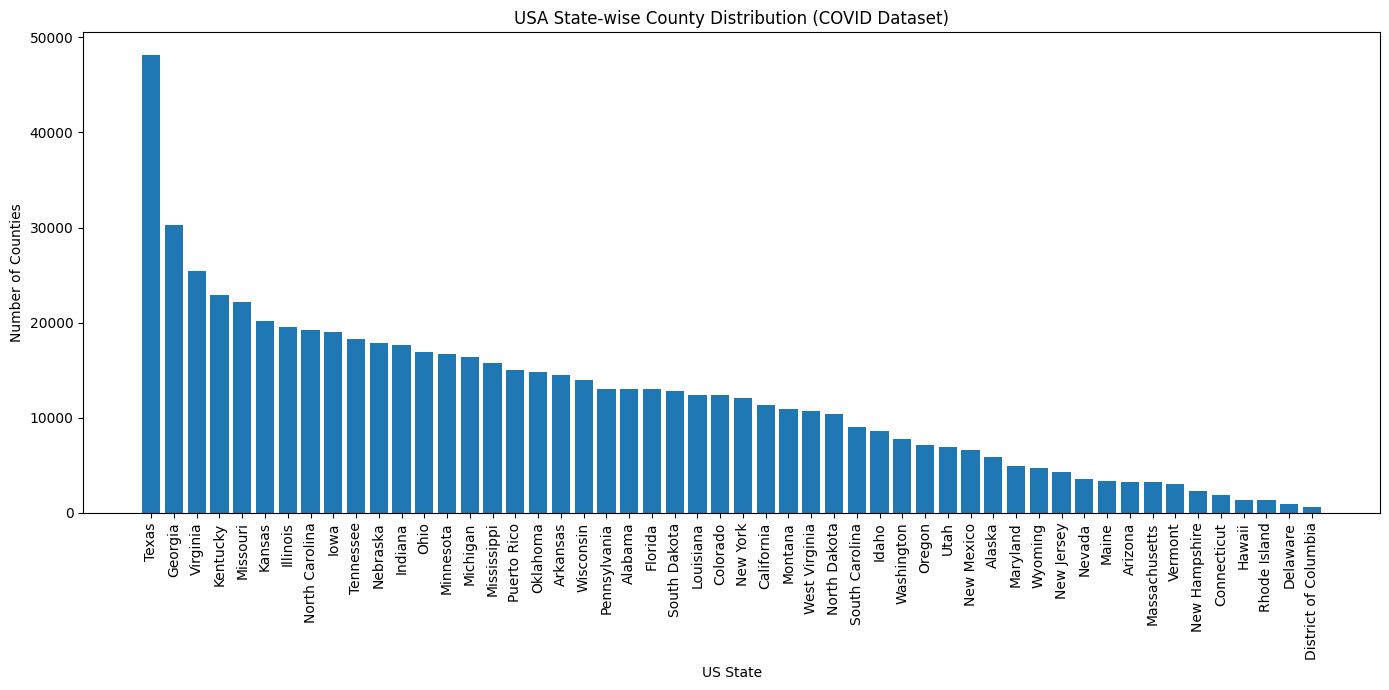

In [77]:
pdf = state_wise_counties.toPandas()

plt.figure(figsize=(14, 7))

plt.bar(
    pdf["Province_State"],
    pdf["Total_Counties"]
)

plt.xlabel("US State")
plt.ylabel("Number of Counties")
plt.title("USA State-wise County Distribution (COVID Dataset)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Task 16: Latitude-Longitude Based Case Clusters

In [78]:
geo_df = clean_complete_df.filter(
    col("Lat").isNotNull() &
    col("Long").isNotNull() &
    col("Confirmed").isNotNull()
)

In [79]:
geo_cluster_df = geo_df.groupBy(
    "Lat",
    "Long"
).agg(
    spark_sum("Confirmed").alias("Total_Confirmed")
)

In [80]:
geo_cluster_df.show(20, truncate=False)

+-------------------+-----------------+---------------+
|Lat                |Long             |Total_Confirmed|
+-------------------+-----------------+---------------+
|-1.8312            |-78.1834         |4678496        |
|48.669             |19.699           |176429         |
|32.427908          |53.68804599999999|19339267       |
|33.886917          |9.537499         |126590         |
|40.1431            |47.5769          |1134717        |
|21.0079            |-10.9408         |219095         |
|9.9456             |-9.6966          |403605         |
|41.9029            |12.4534          |1356           |
|3.9193             |-56.0278         |32247          |
|-11.2027           |17.8739          |22662          |
|17.607789          |8.081666         |102223         |
|7.54               |-5.5471          |611062         |
|-35.6751           |-71.543          |16935654       |
|4.5709             |-74.2973         |6893122        |
|-18.766947000000002|46.869107        |207296   

In [81]:
geo_pd = geo_cluster_df.toPandas()

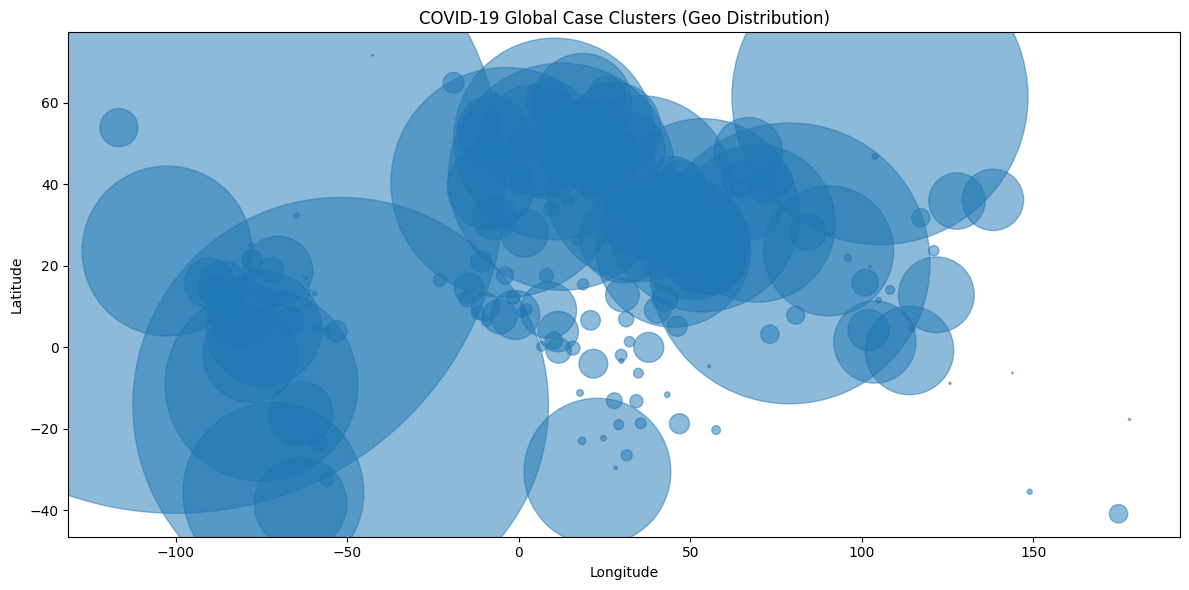

In [82]:
plt.figure(figsize=(12, 6))

plt.scatter(
    geo_pd["Long"],
    geo_pd["Lat"],
    s=geo_pd["Total_Confirmed"] / 1000,  # bubble size scaling
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("COVID-19 Global Case Clusters (Geo Distribution)")

plt.tight_layout()
plt.show()

# Module 8

## Task 17: Recovery Rate Analysis

In [83]:
recovery_df = country_latest_df.filter(
    (col("Confirmed") > 0) &
    col("Recovered").isNotNull()
)

In [84]:

recovery_df = recovery_df.withColumn(
    "Recovery_Rate",
    round(
        (col("Recovered") / col("Confirmed")) * 100,
        2
    )
)

In [85]:
best_recovery = recovery_df.select(
    "Country/Region",
    "Confirmed",
    "Recovered",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").desc()
).limit(10)

print("Top 10 Best Recovery Countries")
best_recovery.show(truncate=False)

Top 10 Best Recovery Countries
+--------------+---------+---------+-------------+
|Country/Region|Confirmed|Recovered|Recovery_Rate|
+--------------+---------+---------+-------------+
|Holy See      |12       |12       |100.0        |
|Grenada       |23       |23       |100.0        |
|Dominica      |18       |18       |100.0        |
|Djibouti      |5059     |4977     |98.38        |
|Iceland       |1854     |1823     |98.33        |
|Brunei        |141      |138      |97.87        |
|New Zealand   |1557     |1514     |97.24        |
|Qatar         |109597   |106328   |97.02        |
|Malaysia      |8904     |8601     |96.6         |
|Mauritius     |344      |332      |96.51        |
+--------------+---------+---------+-------------+



In [86]:
worst_recovery = recovery_df.select(
    "Country/Region",
    "Confirmed",
    "Recovered",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").asc()
).limit(10)

print("Top 10 Worst Recovery Countries")
worst_recovery.show(truncate=False)

Top 10 Worst Recovery Countries
+--------------+---------+---------+-------------+
|Country/Region|Confirmed|Recovered|Recovery_Rate|
+--------------+---------+---------+-------------+
|Canada        |116458   |0        |0.0          |
|Mozambique    |1701     |0        |0.0          |
|Serbia        |24141    |0        |0.0          |
|Sweden        |79395    |0        |0.0          |
|Syria         |674      |0        |0.0          |
|Timor-Leste   |24       |0        |0.0          |
|Netherlands   |53413    |189      |0.35         |
|United Kingdom|301708   |1437     |0.48         |
|Namibia       |1843     |101      |5.48         |
|Botswana      |739      |63       |8.53         |
+--------------+---------+---------+-------------+



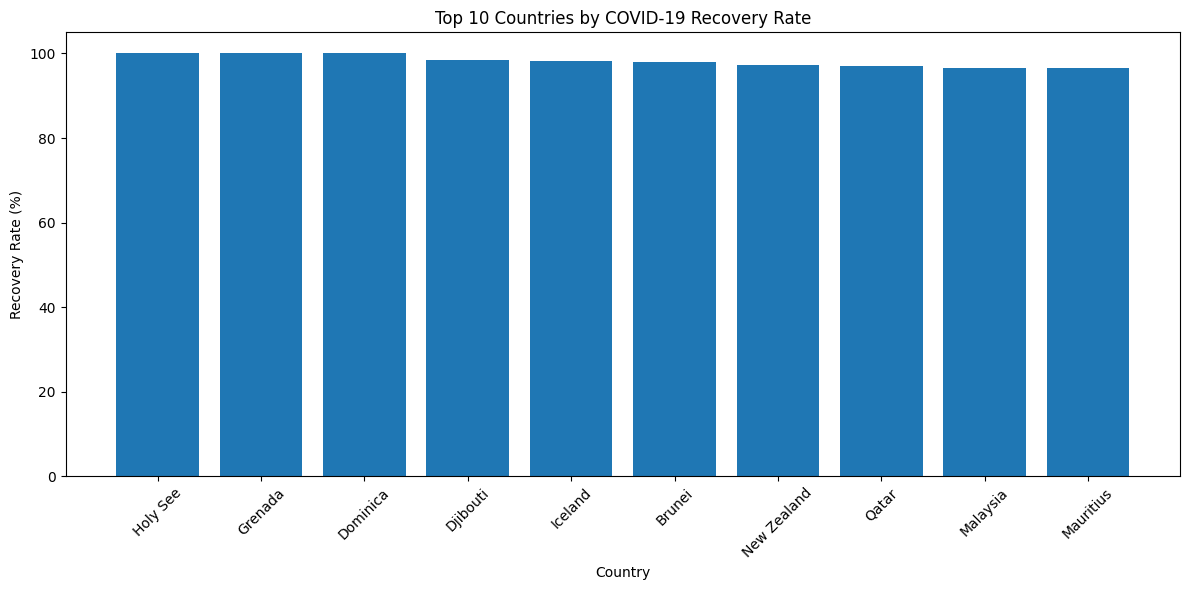

In [87]:
best_pd = best_recovery.toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    best_pd["Country/Region"],
    best_pd["Recovery_Rate"]
)

plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")
plt.title("Top 10 Countries by COVID-19 Recovery Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Task 18: Active Case Burden Analysis


In [88]:
active_case_df = country_latest_df.filter(
    col("Active").isNotNull() &
    col("Recovered").isNotNull()
)

In [89]:
high_risk_countries = active_case_df.filter(
    col("Active") > col("Recovered")
)

In [90]:
high_risk_countries = high_risk_countries.withColumn(
    "Burden_Ratio",
    when(
        col("Recovered") == 0,
        None
    ).otherwise(
        round(
            col("Active") / col("Recovered"),
            2
        )
    )
)

In [91]:

high_risk_countries = high_risk_countries.select(
    "Country/Region",
    "Confirmed",
    "Active",
    "Recovered",
    "Deaths",
    "Burden_Ratio"
)


In [92]:
high_risk_countries = high_risk_countries.filter(
    col("Burden_Ratio").isNotNull()
)

high_risk_countries = high_risk_countries.orderBy(
    col("Burden_Ratio").desc()
)

In [93]:
print("High-Risk Countries (Active Cases > Recovered Cases)")

high_risk_countries.show(
    50,
    truncate=False
)

High-Risk Countries (Active Cases > Recovered Cases)
+------------------------+---------+-------+---------+------+------------+
|Country/Region          |Confirmed|Active |Recovered|Deaths|Burden_Ratio|
+------------------------+---------+-------+---------+------+------------+
|Netherlands             |53413    |47064  |189      |6160  |249.02      |
|United Kingdom          |301708   |254427 |1437     |45844 |177.05      |
|Namibia                 |1843     |1734   |101      |8     |17.17       |
|Botswana                |739      |674    |63       |2     |10.7        |
|Honduras                |39741    |33536  |5039     |1166  |6.66        |
|Papua New Guinea        |62       |51     |11       |0     |4.64        |
|Zimbabwe                |2704     |2126   |542      |36    |3.92        |
|Gambia                  |326      |252    |66       |8     |3.82        |
|Libya                   |2827     |2186   |577      |64    |3.79        |
|Costa Rica              |15841    |11902  |382

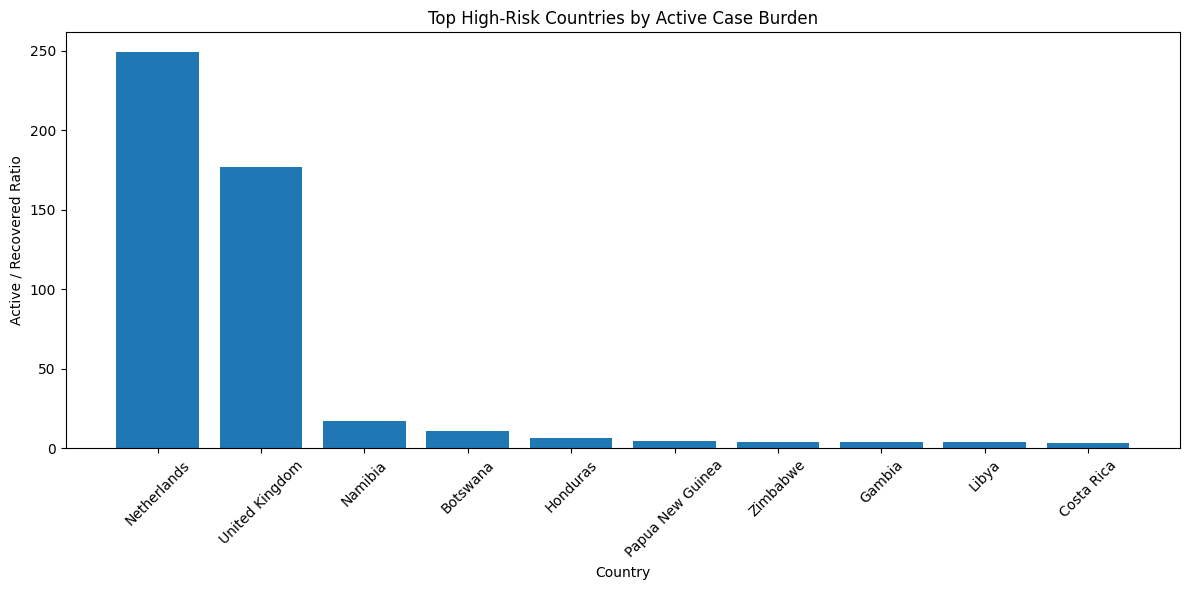

In [94]:
risk_pd = high_risk_countries.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    risk_pd["Country/Region"],
    risk_pd["Burden_Ratio"]
)

plt.xlabel("Country")
plt.ylabel("Active / Recovered Ratio")
plt.title("Top High-Risk Countries by Active Case Burden")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Task 19: Identify Pandemic Peaks


In [95]:
max_cases_value = day_wise_df.agg(
    spark_max("New cases").alias("Max_New_Cases")
).collect()[0]["Max_New_Cases"]

peak_cases_df = day_wise_df.filter(
    col("New cases") == max_cases_value
)

print("Peak New Cases Day")
peak_cases_df.select(
    "Date",
    "New cases"
).show(truncate=False)

Peak New Cases Day
+----------+---------+
|Date      |New cases|
+----------+---------+
|2020-07-23|282756   |
+----------+---------+



In [96]:

max_deaths_value = day_wise_df.agg(
    spark_max("New deaths").alias("Max_New_Deaths")
).collect()[0]["Max_New_Deaths"]

peak_deaths_df = day_wise_df.filter(
    col("New deaths") == max_deaths_value
)

print("Peak New Deaths Day")
peak_deaths_df.select(
    "Date",
    "New deaths"
).show(truncate=False)

Peak New Deaths Day
+----------+----------+
|Date      |New deaths|
+----------+----------+
|2020-07-23|9966      |
+----------+----------+



In [97]:
trend_df = day_wise_df.select(
    "Date",
    "New cases",
    "New deaths"
).orderBy("Date")

trend_df.show(10, truncate=False)

+----------+---------+----------+
|Date      |New cases|New deaths|
+----------+---------+----------+
|2020-01-22|0        |0         |
|2020-01-23|99       |1         |
|2020-01-24|287      |8         |
|2020-01-25|493      |16        |
|2020-01-26|684      |14        |
|2020-01-27|809      |26        |
|2020-01-28|2651     |49        |
|2020-01-29|588      |2         |
|2020-01-30|2068     |38        |
|2020-01-31|1693     |42        |
+----------+---------+----------+
only showing top 10 rows


In [98]:
trend_pd = trend_df.toPandas()

trend_pd["Date"] = pd.to_datetime(trend_pd["Date"])

In [99]:
peak_cases_date = peak_cases_df.collect()[0]["Date"]
peak_cases_count = peak_cases_df.collect()[0]["New cases"]

peak_deaths_date = peak_deaths_df.collect()[0]["Date"]
peak_deaths_count = peak_deaths_df.collect()[0]["New deaths"]


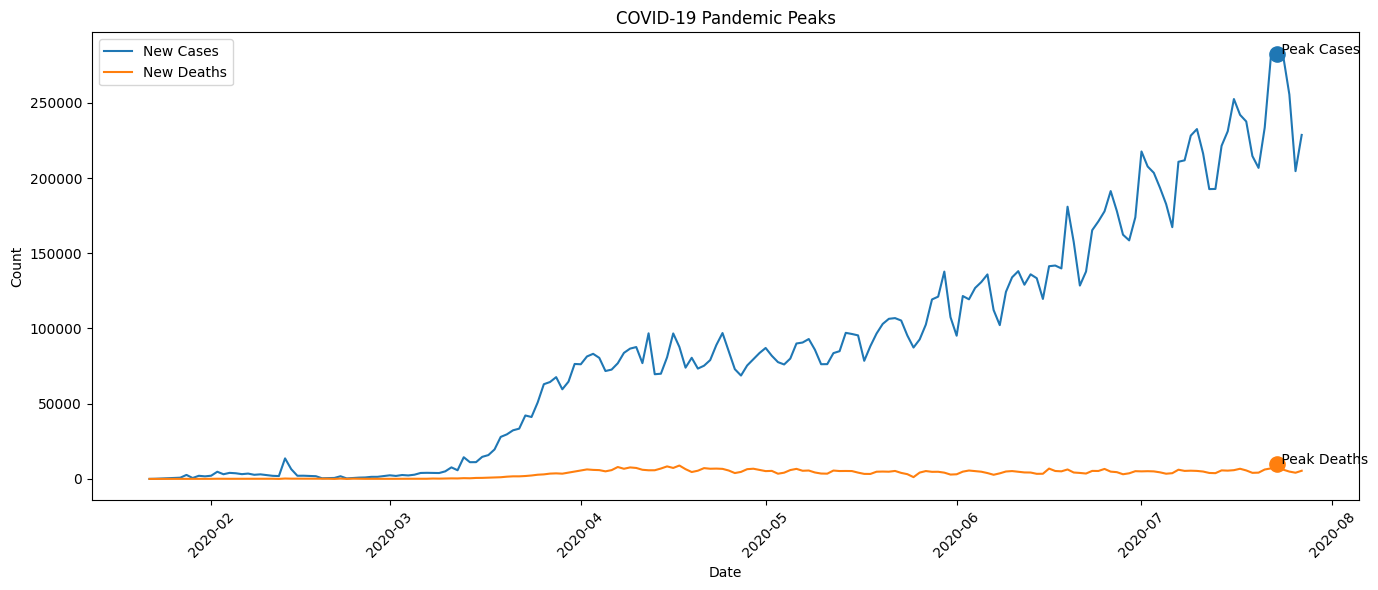

In [100]:
plt.figure(figsize=(14, 6))

plt.plot(
    trend_pd["Date"],
    trend_pd["New cases"],
    label="New Cases"
)

plt.plot(
    trend_pd["Date"],
    trend_pd["New deaths"],
    label="New Deaths"
)

plt.scatter(
    pd.to_datetime(peak_cases_date),
    peak_cases_count,
    s=120
)

plt.scatter(
    pd.to_datetime(peak_deaths_date),
    peak_deaths_count,
    s=120
)

plt.text(
    pd.to_datetime(peak_cases_date),
    peak_cases_count,
    " Peak Cases"
)

plt.text(
    pd.to_datetime(peak_deaths_date),
    peak_deaths_count,
    " Peak Deaths"
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("COVID-19 Pandemic Peaks")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Module 9

## Task 20: Create Severity Category

In [101]:
severity_df = country_latest_df.withColumn(
    "Severity_Category",

    when(col("Confirmed") < 10000, "Low")

    .when(
        (col("Confirmed") >= 10000) &
        (col("Confirmed") < 100000),
        "Medium"
    )

    .when(
        (col("Confirmed") >= 100000) &
        (col("Confirmed") < 1000000),
        "High"
    )

    .otherwise("Critical")
)

In [102]:
severity_df.select(
    "Country/Region",
    "Confirmed",
    "Severity_Category"
).show(20, truncate=False)

+-------------------+---------+-----------------+
|Country/Region     |Confirmed|Severity_Category|
+-------------------+---------+-----------------+
|Afghanistan        |36263    |Medium           |
|Albania            |4880     |Low              |
|Algeria            |27973    |Medium           |
|Andorra            |907      |Low              |
|Angola             |950      |Low              |
|Antigua and Barbuda|86       |Low              |
|Argentina          |167416   |High             |
|Armenia            |37390    |Medium           |
|Australia          |15303    |Medium           |
|Austria            |20558    |Medium           |
|Azerbaijan         |30446    |Medium           |
|Bahamas            |382      |Low              |
|Bahrain            |39482    |Medium           |
|Bangladesh         |226225   |High             |
|Barbados           |110      |Low              |
|Belarus            |67251    |Medium           |
|Belgium            |66428    |Medium           |


In [103]:
severity_summary = severity_df.groupBy(
    "Severity_Category"
).agg(
    count("*").alias("Country_Count")
)


In [104]:
severity_summary.show(truncate=False)

+-----------------+-------------+
|Severity_Category|Country_Count|
+-----------------+-------------+
|High             |21           |
|Low              |107          |
|Medium           |56           |
|Critical         |3            |
+-----------------+-------------+



In [105]:
severity_pd = severity_summary.toPandas()

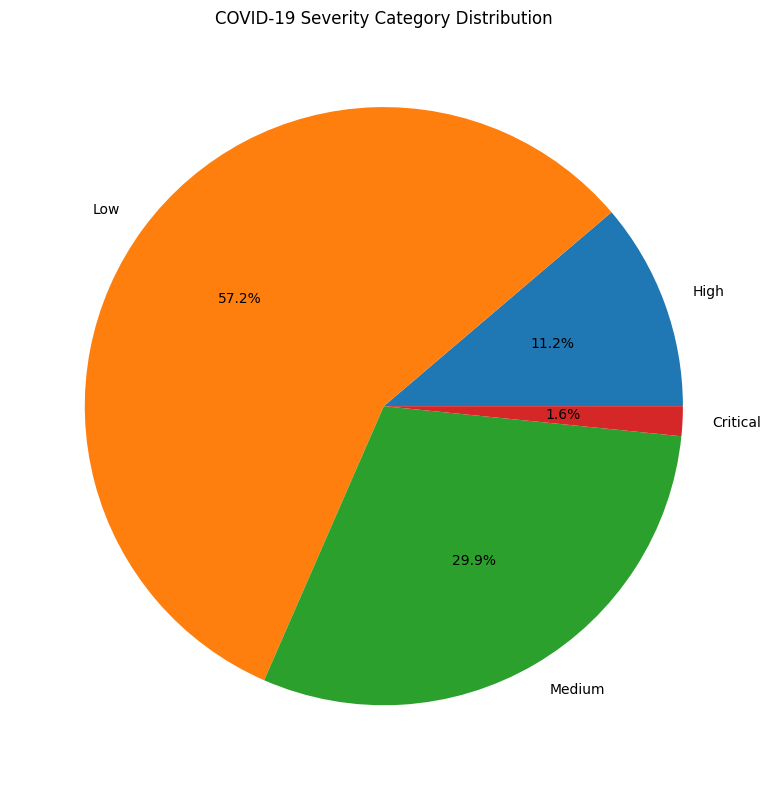

In [106]:
plt.figure(figsize=(8, 8))

plt.pie(
    severity_pd["Country_Count"],
    labels=severity_pd["Severity_Category"],
    autopct="%1.1f%%"
)

plt.title("COVID-19 Severity Category Distribution")

plt.tight_layout()
plt.show()

# Module 10

## Task 21: Build COVID Analytics Pipeline

In [107]:
spark = SparkSession.builder \
    .appName("COVID19 Analytics Pipeline") \
    .getOrCreate()

In [108]:
full_grouped_df = spark.read.csv(
    "data/full_grouped.csv",
    header=True,
    inferSchema=True
)

clean_complete_df = spark.read.csv(
    "data/covid_19_clean_complete.csv",
    header=True,
    inferSchema=True
)

country_latest_df = spark.read.csv(
    "data/country_wise_latest.csv",
    header=True,
    inferSchema=True
)

day_wise_df = spark.read.csv(
    "data/day_wise.csv",
    header=True,
    inferSchema=True
)

usa_county_df = spark.read.csv(
    "data/usa_county_wise.csv",
    header=True,
    inferSchema=True
)

worldometer_df = spark.read.csv(
    "data/worldometer_data.csv",
    header=True,
    inferSchema=True
)

In [109]:
clean_complete_df = clean_complete_df.fillna({
    "Province/State": "Unknown"
})

# Remove duplicates
full_grouped_df = full_grouped_df.dropDuplicates([
    "Country/Region",
    "Date"
])

clean_complete_df = clean_complete_df.dropDuplicates([
    "Country/Region",
    "Date"
])

In [110]:
def standardize_country_names(df, column_name):

    return df.withColumn(
        column_name,

        when(col(column_name) == "US", "USA")
        .when(col(column_name) == "Korea, South", "South Korea")
        .when(col(column_name) == "UK", "United Kingdom")
        .when(col(column_name) == "UAE", "United Arab Emirates")
        .otherwise(col(column_name))
    )

full_grouped_df = standardize_country_names(
    full_grouped_df,
    "Country/Region"
)

country_latest_df = standardize_country_names(
    country_latest_df,
    "Country/Region"
)

worldometer_df = standardize_country_names(
    worldometer_df,
    "Country/Region"
)

In [111]:
top_countries = country_latest_df.select(
    "Country/Region",
    "Confirmed"
).orderBy(
    col("Confirmed").desc()
).limit(10)

In [112]:
region_summary = full_grouped_df.groupBy(
    "WHO Region"
).agg(
    sum("Confirmed").alias("Total_Confirmed"),
    sum("Deaths").alias("Total_Deaths"),
    sum("Recovered").alias("Total_Recovered")
)


In [113]:
daily_trends = day_wise_df.select(
    "Date",
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active",
    "New cases",
    "New deaths"
).orderBy("Date")


In [114]:
mortality_report = country_latest_df.withColumn(
    "Death_Rate",
    round(
        (col("Deaths") / col("Confirmed")) * 100,
        2
    )
).filter(
    col("Confirmed") > 0
).select(
    "Country/Region",
    "Confirmed",
    "Deaths",
    "Death_Rate"
).orderBy(
    col("Death_Rate").desc()
)

In [115]:
recovery_report = country_latest_df.withColumn(
    "Recovery_Rate",
    round(
        (col("Recovered") / col("Confirmed")) * 100,
        2
    )
).filter(
    col("Confirmed") > 0
).select(
    "Country/Region",
    "Confirmed",
    "Recovered",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").desc()
)

In [116]:
joined_df = country_latest_df.join(
    worldometer_df,
    on="Country/Region",
    how="inner"
)

In [117]:
import os

os.makedirs("output", exist_ok=True)

top_countries_pd = top_countries.toPandas()
region_summary_pd = region_summary.toPandas()
daily_trends_pd = daily_trends.toPandas()
mortality_report_pd = mortality_report.toPandas()
recovery_report_pd = recovery_report.toPandas()

top_countries_pd.to_csv(
    "output/top_countries.csv",
    index=False
)

region_summary_pd.to_csv(
    "output/region_summary.csv",
    index=False
)

daily_trends_pd.to_csv(
    "output/daily_trends.csv",
    index=False
)

mortality_report_pd.to_csv(
    "output/mortality_report.csv",
    index=False
)

recovery_report_pd.to_csv(
    "output/recovery_report.csv",
    index=False
)

print("CSV files exported successfully")

CSV files exported successfully


In [118]:
import os

os.makedirs("output", exist_ok=True)

top_countries_pd = top_countries.toPandas()
region_summary_pd = region_summary.toPandas()
daily_trends_pd = daily_trends.toPandas()
mortality_report_pd = mortality_report.toPandas()
recovery_report_pd = recovery_report.toPandas()

def clean_df(df):
    df = df.copy()
    for col_name in df.columns:
        df[col_name] = df[col_name].astype(str)
    return df

top_countries_pd = clean_df(top_countries_pd)
region_summary_pd = clean_df(region_summary_pd)
daily_trends_pd = clean_df(daily_trends_pd)
mortality_report_pd = clean_df(mortality_report_pd)
recovery_report_pd = clean_df(recovery_report_pd)

top_countries_pd.to_csv("output/top_countries.csv", index=False)
region_summary_pd.to_csv("output/region_summary.csv", index=False)
daily_trends_pd.to_csv("output/daily_trends.csv", index=False)
mortality_report_pd.to_csv("output/mortality_report.csv", index=False)
recovery_report_pd.to_csv("output/recovery_report.csv", index=False)

top_countries_pd.to_parquet(
    "output/top_countries.parquet",
    engine="fastparquet",
    index=False
)

region_summary_pd.to_parquet(
    "output/region_summary.parquet",
    engine="fastparquet",
    index=False
)

daily_trends_pd.to_parquet(
    "output/daily_trends.parquet",
    engine="fastparquet",
    index=False
)

mortality_report_pd.to_parquet(
    "output/mortality_report.parquet",
    engine="fastparquet",
    index=False
)

recovery_report_pd.to_parquet(
    "output/recovery_report.parquet",
    engine="fastparquet",
    index=False
)

print("✅ All CSV and Parquet files exported successfully!")

ImportError: `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [ ]:
print("Top Countries")
top_countries.show(truncate=False)

print("Region Summary")
region_summary.show(truncate=False)

print("Mortality Report")
mortality_report.show(truncate=False)

print("Recovery Report")
recovery_report.show(truncate=False)

Top Countries
+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+

Region Summary
+---------------------+---------------+------------+---------------+
|WHO Region           |Total_Confirmed|Total_Deaths|Total_Recovered|
+---------------------+---------------+------------+---------------+
|Europe               |248879793      |19271040    |123202075      |
|Western Pacific      |26374411       |932430      |18861950       |
|Africa               |21791827       |439978      |11193730       |
|Eastern Mediterranean|74082892       |1924029     |48050703       |
|Americas             |402261194      |19359292    |157069444      |
|South-East Asia      |55118365       |1